# Llm deliberation clean forced choice boundary

This notebook belongs to the project's sequential measurement and validation programme. Read its result as evidence about behavioural validity, representation, comparator strength, timing, information matching, or mechanistic calibration as appropriate. Legacy H1/H_priv identifiers may remain inside code, saved paths, or frozen schemas for reproducibility; they are not the object being "found" by the current analysis.

**Repository framing.** The current paper separates target-specific representation from predictive privilege. A positive neural result is interpreted only after behavioural validity, control, comparator-strength, timing, and information-set checks.


# Latent reservations — Notebook 07d
## Clean forced-choice scalar acceptance boundary

This is a one-shot measurement repair for the native-format scalar-boundary branch.

The previous branch successfully removed parser-format failures, but some free-form generations still treated the controlled candidate as an invitation to resume ordinary negotiation. That produced decisions such as accepting a below-minimum scalar candidate while describing a different future deal.

This notebook removes that ambiguity without changing the frozen strategic states or candidate score grid.

### What stays fixed

- the same 30 immutable LLM-Deliberation parent states;
- the same five source trajectories;
- the same candidate score grids frozen before the earlier boundary outcomes;
- the same local subject checkpoint;
- the same raw-boundary and continuation-premium targets;
- the same grouped nested evaluation and strong text-visible baselines.

### What changes

The controlled replay is now a **binary forced-choice task**, not a free-form negotiation turn.

The controlled parent text is reconstructed from:

1. the benchmark's original private rules / score information;
2. the frozen public negotiation history;
3. a standardized representation of the original greedy/cooperative incentive;
4. a project-owned controlled-replay rule.

The old "your turn to talk", scratchpad, proposal, answer-tag, and plan-format instructions are excluded from the controlled prompt.

For each candidate, the model is asked to choose between exactly two legal actions:

- `0` = REJECT and return to the exact frozen state;
- `1` = ACCEPT and finalize immediately at the verified scalar score.

The model receives one forward pass. The consequential controlled choice is the higher-logit legal action token. No free-form generation, parser, or retry is involved.

The **primary activation is still captured from the parent state before any candidate score is revealed**. Therefore the reader is not predicting a token from the same candidate-conditioned forward pass.

Outputs:

`/workspace/latent-reservations/notebook_outputs/07d_llm_deliberation_clean_forced_choice_boundary/<RUN_ID>/`


In [1]:
NOTEBOOK_BUILD = "latent-reservations-notebook07d-clean-forced-choice-boundary-v1"
print("=" * 92)
print(f"NOTEBOOK BUILD: {NOTEBOOK_BUILD}")
print("LLM-Deliberation clean forced-choice scalar acceptance boundary")
print("=" * 92)


NOTEBOOK BUILD: latent-reservations-notebook07d-clean-forced-choice-boundary-v1
LLM-Deliberation clean forced-choice scalar acceptance boundary


## 1. Dependencies


In [2]:
import importlib.util
import subprocess
import sys

packages = [
    "transformers>=4.45,<5",
    "accelerate>=0.30,<2",
    "safetensors>=0.4",
    "numpy<2",
    "pandas>=2,<3",
    "scipy>=1.12,<2",
    "scikit-learn>=1.4,<2",
    "matplotlib>=3.8,<4",
    "tqdm>=4.66",
]
subprocess.run([sys.executable, "-m", "pip", "install", *packages], check=True)

if importlib.util.find_spec("torch") is None:
    raise RuntimeError("PyTorch is required.")

print("Notebook 07d dependencies ready.")


Notebook 07d dependencies ready.


## 2. Paths and isolated run directory


In [3]:
from __future__ import annotations

import hashlib
import json
import os
import re
import shutil
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

PROJECT_ROOT = Path(
    os.environ.get("LR_PROJECT_ROOT", "/workspace/latent-reservations")
).expanduser().resolve()

NOTEBOOK_SLUG = "07d_llm_deliberation_clean_forced_choice_boundary"
RUN_ID = os.environ.get(
    "LR_RUN_ID",
    datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ"),
)

NOTEBOOK_OUTPUT_BASE = PROJECT_ROOT / "notebook_outputs" / NOTEBOOK_SLUG
RUN_OUTPUT_DIR = NOTEBOOK_OUTPUT_BASE / RUN_ID

MANIFEST_DIR = RUN_OUTPUT_DIR / "manifests"
INPUT_DIR = RUN_OUTPUT_DIR / "inputs"
PARENT_STATE_DIR = INPUT_DIR / "parent_states"
CANDIDATE_BANK_DIR = INPUT_DIR / "candidate_banks"

DATA_DIR = RUN_OUTPUT_DIR / "data"
PARENT_TEXT_DIR = DATA_DIR / "controlled_parent_text"
PARENT_ACTIVATION_DIR = DATA_DIR / "parent_activations"
CHOICE_DIR = DATA_DIR / "branches" / "forced_choices"
AUDITOR_DIR = DATA_DIR / "branches" / "auditor"
DERIVED_DIR = DATA_DIR / "derived"

TABLE_DIR = RUN_OUTPUT_DIR / "results" / "tables"
FIGURE_DIR = RUN_OUTPUT_DIR / "results" / "figures"

HF_CACHE_DIR = Path(
    os.environ.get("HF_HOME", "/workspace/.cache/huggingface")
).expanduser().resolve()

for p in [
    MANIFEST_DIR,
    PARENT_STATE_DIR,
    CANDIDATE_BANK_DIR,
    PARENT_TEXT_DIR,
    PARENT_ACTIVATION_DIR,
    CHOICE_DIR,
    AUDITOR_DIR,
    DERIVED_DIR,
    TABLE_DIR,
    FIGURE_DIR,
]:
    p.mkdir(parents=True, exist_ok=True)

NOTEBOOK_OUTPUT_BASE.mkdir(parents=True, exist_ok=True)
(NOTEBOOK_OUTPUT_BASE / "latest_run.json").write_text(json.dumps({
    "notebook_slug": NOTEBOOK_SLUG,
    "run_id": RUN_ID,
    "run_output_dir": str(RUN_OUTPUT_DIR),
    "updated_at_utc": datetime.now(timezone.utc).isoformat(),
}, indent=2))

print(f"RUN_OUTPUT_DIR = {RUN_OUTPUT_DIR}")
print(f"HF_CACHE_DIR   = {HF_CACHE_DIR}")


RUN_OUTPUT_DIR = /workspace/latent-reservations/notebook_outputs/07d_llm_deliberation_clean_forced_choice_boundary/20260814T122756Z
HF_CACHE_DIR   = /workspace/.cache/huggingface


## 3. Snapshot the same pre-outcome states and candidate score banks

Prefer the latest completed 07c input snapshot. If it is unavailable, fall back to 07b.

Only parent states and candidate score banks are copied. No earlier candidate decisions, revealed boundaries, probe predictions, or auditor predictions are reused.


In [4]:
SOURCE_RUN_DIR = None
SOURCE_LABEL = None

for slug in [
    "07c_llm_deliberation_native_format_scalar_boundary",
    "07b_llm_deliberation_scalar_acceptance_boundary",
]:
    base = PROJECT_ROOT / "notebook_outputs" / slug
    latest = base / "latest_run.json"
    if not latest.exists():
        continue
    meta = json.loads(latest.read_text())
    candidate_run = Path(meta["run_output_dir"])

    if slug.startswith("07c"):
        parent_src = candidate_run / "inputs" / "parent_states"
        bank_src = candidate_run / "inputs" / "candidate_banks"
    else:
        parent_src = candidate_run / "inputs" / "parent_states"
        bank_src = candidate_run / "inputs" / "candidate_banks"

    if (
        parent_src.exists()
        and bank_src.exists()
        and len(list(parent_src.glob("*.json"))) == 30
        and len(list(bank_src.glob("*.json"))) == 30
    ):
        SOURCE_RUN_DIR = candidate_run
        SOURCE_LABEL = slug
        SOURCE_PARENT_DIR = parent_src
        SOURCE_BANK_DIR = bank_src
        break

if SOURCE_RUN_DIR is None:
    raise FileNotFoundError(
        "Could not locate a complete 30-state parent/candidate snapshot from 07c or 07b."
    )

def sha256_file(path: Path) -> str:
    h = hashlib.sha256()
    with path.open("rb") as f:
        for block in iter(lambda: f.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()

snapshot_rows = []

for src in sorted(SOURCE_PARENT_DIR.glob("*.json")):
    dst = PARENT_STATE_DIR / src.name
    shutil.copy2(src, dst)
    snapshot_rows.append({
        "kind": "parent_state",
        "name": src.name,
        "sha256": sha256_file(dst),
        "size": dst.stat().st_size,
    })

for src in sorted(SOURCE_BANK_DIR.glob("*.json")):
    dst = CANDIDATE_BANK_DIR / src.name
    shutil.copy2(src, dst)
    snapshot_rows.append({
        "kind": "candidate_bank",
        "name": src.name,
        "sha256": sha256_file(dst),
        "size": dst.stat().st_size,
    })

(MANIFEST_DIR / "input_snapshot.json").write_text(json.dumps({
    "source_run": str(SOURCE_RUN_DIR),
    "source_label": SOURCE_LABEL,
    "files": snapshot_rows,
}, indent=2))

print({
    "source_run": str(SOURCE_RUN_DIR),
    "source_label": SOURCE_LABEL,
    "parent_files": len(list(PARENT_STATE_DIR.glob("*.json"))),
    "candidate_banks": len(list(CANDIDATE_BANK_DIR.glob("*.json"))),
})


{'source_run': '/workspace/latent-reservations/notebook_outputs/07c_llm_deliberation_native_format_scalar_boundary/20260814T110150Z', 'source_label': '07c_llm_deliberation_native_format_scalar_boundary', 'parent_files': 30, 'candidate_banks': 30}


## 4. Verify immutable parent states and candidate grids


In [5]:
def canonical_state_hash(payload: dict) -> str:
    raw = json.dumps(
        payload,
        sort_keys=True,
        ensure_ascii=False,
        separators=(",", ":"),
    )
    return hashlib.sha256(raw.encode()).hexdigest()

def sha256_text(text: str) -> str:
    return hashlib.sha256(text.encode("utf-8")).hexdigest()

parent_states = []
candidate_banks = {}

for path in sorted(PARENT_STATE_DIR.glob("*.json")):
    state = json.loads(path.read_text())

    expected = state.get("parent_snapshot_hash")
    check = dict(state)
    check.pop("parent_snapshot_hash", None)

    if expected is not None and canonical_state_hash(check) != expected:
        raise RuntimeError(f"Parent snapshot hash mismatch: {path.name}")

    if sha256_text(state["exact_subject_text"]) != state["observation_hash"]:
        raise RuntimeError(f"Original observation hash mismatch: {path.name}")

    parent_states.append(state)

for path in sorted(CANDIDATE_BANK_DIR.glob("*.json")):
    bank = json.loads(path.read_text())
    candidate_banks[bank["state_id"]] = bank

if len(parent_states) != 30:
    raise RuntimeError(f"Expected 30 parent states; found {len(parent_states)}")
if len(candidate_banks) != 30:
    raise RuntimeError(f"Expected 30 candidate banks; found {len(candidate_banks)}")

state_by_id = {s["state_id"]: s for s in parent_states}
trajectory_ids = sorted({s["trajectory_id"] for s in parent_states})

if len(trajectory_ids) != 5:
    raise RuntimeError(f"Expected five trajectories; found {trajectory_ids}")

trajectory_counts = pd.Series(
    [s["trajectory_id"] for s in parent_states]
).value_counts().sort_index()

if not (trajectory_counts == 6).all():
    raise RuntimeError(
        "Expected six states per trajectory:\n" + trajectory_counts.to_string()
    )

subject_models = sorted({s["subject_model"] for s in parent_states})
upstream_commits = sorted({s["upstream_commit"] for s in parent_states})

if len(subject_models) != 1 or len(upstream_commits) != 1:
    raise RuntimeError("Frozen bank mixes model or upstream provenance.")

SUBJECT_MODEL = subject_models[0]
SUBJECT_REVISION = "main"
UPSTREAM_COMMIT = upstream_commits[0]

for state in parent_states:
    bank = candidate_banks[state["state_id"]]
    if bank["trajectory_id"] != state["trajectory_id"]:
        raise RuntimeError(f"Trajectory mismatch for {state['state_id']}")

    scores = [float(c["score"]) for c in bank["candidates"]]
    if scores != sorted(set(scores)):
        raise RuntimeError(f"Candidate scores are not unique and sorted for {state['state_id']}")

print({
    "states": len(parent_states),
    "trajectories": trajectory_counts.to_dict(),
    "candidate_branches": sum(b["candidate_count"] for b in candidate_banks.values()),
    "subject_model": SUBJECT_MODEL,
    "upstream_commit": UPSTREAM_COMMIT,
})


{'states': 30, 'trajectories': {'trajectory_000': 6, 'trajectory_001': 6, 'trajectory_002': 6, 'trajectory_003': 6, 'trajectory_004': 6}, 'candidate_branches': 490, 'subject_model': 'Qwen/Qwen2.5-7B-Instruct', 'upstream_commit': '78e11e04ba89b9d888cb006f57bad696584a32f1'}


## 5. Reconstruct a clean controlled parent prompt

The benchmark's **substantive state** is preserved:

- original private role and scoring rules;
- explicit minimum;
- public negotiation history;
- original cooperative versus greedy incentive.

The old ordinary-speaking/output contract is not preserved. In particular, this controlled prompt does not ask the model to:

- make a negotiation proposal;
- calculate an issue bundle;
- emit scratchpad XML;
- emit a public answer;
- produce a future plan.

That contract is the nuisance this notebook is removing.

The persona summary is determined solely from the frozen `incentive` field and is fixed before any new choice outcomes are generated.


In [6]:
INCENTIVE_TEXT = {
    "greedy": (
        "Your original strategic stance remains greedy/self-interested: prioritize your own final score, "
        "put little weight on accommodating other parties, and prefer higher-scoring outcomes. "
        "You still cannot accept an outcome below your benchmark minimum."
    ),
    "cooperative": (
        "Your original strategic stance remains cooperative: reaching agreement is important once your "
        "benchmark minimum is satisfied, and you normally value balanced outcomes and accommodation. "
        "You still cannot accept an outcome below your benchmark minimum."
    ),
}

def extract_history_block(state: dict) -> str:
    round_prompt = state["round_prompt"]
    marker = "</HISTORY>"
    if marker not in round_prompt:
        raise RuntimeError(f"No history terminator in {state['state_id']}")
    return round_prompt.split(marker, 1)[0].strip() + " " + marker

CONTROLLED_PARENT_RULE = (
    "\n\n<CONTROLLED_BINARY_REPLAY>\n"
    "This is a measurement replay, not an ordinary speaking turn. "
    "Do not propose, modify, renegotiate, or substitute a different deal in this replay. "
    "No issue bundle will be shown and no issue arithmetic is required. "
    "A later independent branch will show exactly one VERIFIED PRIVATE SCORE. "
    "That number is already calculated from your confidential score sheet. "
    "If you ACCEPT, the negotiation ends immediately and your complete payoff for this replay is exactly "
    "that verified score. All other parties automatically approve; there is no unanimity bonus, side payment, "
    "or later adjustment. If you REJECT, that candidate disappears and you return to this exact frozen state "
    "with all original future negotiation possibilities intact. "
    "Your benchmark minimum remains a hard game rule: a score below the stated minimum cannot be accepted. "
    "No candidate score is present yet, so do not make a decision now.\n"
    "</CONTROLLED_BINARY_REPLAY>"
)

def controlled_parent_text(state: dict) -> str:
    incentive = state["incentive"]
    if incentive not in INCENTIVE_TEXT:
        raise RuntimeError(
            f"Unhandled frozen incentive {incentive!r} in {state['state_id']}"
        )

    return (
        state["initial_prompt"].rstrip()
        + "\n\n"
        + extract_history_block(state)
        + "\n\n<ORIGINAL_STRATEGIC_STANCE>\n"
        + INCENTIVE_TEXT[incentive]
        + "\n</ORIGINAL_STRATEGIC_STANCE>"
        + CONTROLLED_PARENT_RULE
    )

controlled_parent_hashes = {}

for state in parent_states:
    text = controlled_parent_text(state)
    sid = state["state_id"]

    forbidden_fragments = [
        "Please use a scratchpad",
        "Enclose the scratchpad",
        "After the final answer",
        "Now it is your turn to talk",
    ]
    for fragment in forbidden_fragments:
        if fragment in text:
            raise RuntimeError(
                f"Old speaking/output contract leaked into controlled prompt for {sid}: {fragment}"
            )

    payload = {
        "state_id": sid,
        "source_observation_hash": state["observation_hash"],
        "incentive": state["incentive"],
        "controlled_parent_text": text,
    }
    digest = canonical_state_hash(payload)
    controlled_parent_hashes[sid] = digest

    (PARENT_TEXT_DIR / f"{sid}.json").write_text(json.dumps({
        **payload,
        "controlled_parent_hash": digest,
    }, indent=2, ensure_ascii=False))

print({
    "controlled_parent_prompts": len(controlled_parent_hashes),
    "example_state": parent_states[0]["state_id"],
    "example_tail": controlled_parent_text(parent_states[0])[-1400:],
})


{'controlled_parent_prompts': 30, 'example_state': 'ld_000_trajectory_000_department_of_tourism', 'example_tail': '- Secure the federal loan (D1) as initially proposed.\n- Provide some compensation to other cities (E2) to address their concerns.\n</PLAN> </HISTORY>\n\n<ORIGINAL_STRATEGIC_STANCE>\nYour original strategic stance remains greedy/self-interested: prioritize your own final score, put little weight on accommodating other parties, and prefer higher-scoring outcomes. You still cannot accept an outcome below your benchmark minimum.\n</ORIGINAL_STRATEGIC_STANCE>\n\n<CONTROLLED_BINARY_REPLAY>\nThis is a measurement replay, not an ordinary speaking turn. Do not propose, modify, renegotiate, or substitute a different deal in this replay. No issue bundle will be shown and no issue arithmetic is required. A later independent branch will show exactly one VERIFIED PRIVATE SCORE. That number is already calculated from your confidential score sheet. If you ACCEPT, the negotiation ends imm

## 6. Freeze folds and analysis protocol before loading the model

The five source trajectories are the five folds.

For each outer test trajectory, the next trajectory cyclically is validation; the other three are inner training.

Behavioral validity gates:

- zero forced ACCEPT choices below the explicit minimum;
- maximum-score ACCEPT rate ≥ 90%;
- at least two-thirds of states contain both ACCEPT and REJECT;
- no more than 20% of states have an adjacent ACCEPT→REJECT reversal as score rises.

The unrestricted global next token is recorded only as a compliance diagnostic. It is **not** the controlled action.

Primary target:

`revealed scalar boundary normalized to the legal private-score range`.

Secondary target:

`continuation premium = revealed boundary - explicit minimum`.


In [7]:
trajectory_to_fold = {
    trajectory_id: i
    for i, trajectory_id in enumerate(sorted(trajectory_ids))
}

fold_protocol = {
    "trajectory_to_fold": trajectory_to_fold,
    "outer_folds": {
        str(outer): {
            "test_fold": outer,
            "validation_fold": (outer + 1) % 5,
            "inner_train_folds": [
                f for f in range(5)
                if f not in {outer, (outer + 1) % 5}
            ],
        }
        for outer in range(5)
    },
}

protocol_freeze = {
    "notebook_build": NOTEBOOK_BUILD,
    "source_run": str(SOURCE_RUN_DIR),
    "parent_states": 30,
    "candidate_scores": "same frozen candidate score banks used by the prior scalar-boundary branches",
    "controlled_parent_transform": (
        "original initial private rules + frozen history + frozen incentive summary + "
        "controlled binary replay; ordinary speaking/output contract excluded"
    ),
    "parent_activation_timing": "controlled parent state before candidate score is revealed",
    "controlled_action": (
        "forced binary choice from relative next-token logits over canonical legal tokens; "
        "0=REJECT, 1=ACCEPT"
    ),
    "unrestricted_global_argmax": "diagnostic only",
    "behavioral_gates": {
        "below_minimum_accept_count_max": 0,
        "maximum_score_accept_rate_min": 0.90,
        "uncensored_state_rate_min": 2.0 / 3.0,
        "state_monotonicity_violation_rate_max": 0.20,
    },
    "primary_target": "binary forced-choice isotonic boundary normalized to legal score range",
    "secondary_target": "continuation premium = revealed boundary - explicit minimum",
    "primary_delta": "matched text auditor MAE - activation reader MAE",
    "conservative_text_suite": [
        "matched generative auditor",
        "trained character-TFIDF",
        "assigned-threshold baseline",
    ],
    "conservative_nonactivation_suite": [
        "matched generative auditor",
        "trained character-TFIDF",
        "assigned-threshold baseline",
        "structured state",
        "fold-wise constant median",
    ],
    "fold_protocol": fold_protocol,
}

(MANIFEST_DIR / "protocol_freeze.json").write_text(
    json.dumps(protocol_freeze, indent=2)
)
(DERIVED_DIR / "trajectory_folds.json").write_text(
    json.dumps(fold_protocol, indent=2)
)

print(json.dumps(protocol_freeze, indent=2))


{
  "notebook_build": "latent-reservations-notebook07d-clean-forced-choice-boundary-v1",
  "source_run": "/workspace/latent-reservations/notebook_outputs/07c_llm_deliberation_native_format_scalar_boundary/20260814T110150Z",
  "parent_states": 30,
  "candidate_scores": "same frozen candidate score banks used by the prior scalar-boundary branches",
  "controlled_parent_transform": "original initial private rules + frozen history + frozen incentive summary + controlled binary replay; ordinary speaking/output contract excluded",
  "parent_activation_timing": "controlled parent state before candidate score is revealed",
  "controlled_action": "forced binary choice from relative next-token logits over canonical legal tokens; 0=REJECT, 1=ACCEPT",
  "unrestricted_global_argmax": "diagnostic only",
  "behavioral_gates": {
    "below_minimum_accept_count_max": 0,
    "maximum_score_accept_rate_min": 0.9,
    "uncensored_state_rate_min": 0.6666666666666666,
    "state_monotonicity_violation_rate_

## 7. Load the same local subject and select canonical binary tokens

The controlled action uses one fixed tokenizer token for `0` and one fixed tokenizer token for `1`.

A leading-space token is preferred when available because the prompt ends immediately before the action slot. If unavailable, the bare digit token is used.

The same canonical token definition is used for every state.


In [8]:
import torch
from safetensors.torch import load_file, save_file
from transformers import AutoModelForCausalLM, AutoTokenizer

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is required for Notebook 07d.")

tokenizer = AutoTokenizer.from_pretrained(
    SUBJECT_MODEL,
    revision=SUBJECT_REVISION,
    cache_dir=str(HF_CACHE_DIR),
)
model = AutoModelForCausalLM.from_pretrained(
    SUBJECT_MODEL,
    revision=SUBJECT_REVISION,
    cache_dir=str(HF_CACHE_DIR),
    dtype=torch.bfloat16,
    device_map={"": 0},
    low_cpu_mem_usage=True,
)
model.eval()

def find_decoder_layers(m):
    candidates = [
        ("model.layers", getattr(getattr(m, "model", None), "layers", None)),
        ("transformer.h", getattr(getattr(m, "transformer", None), "h", None)),
        ("gpt_neox.layers", getattr(getattr(m, "gpt_neox", None), "layers", None)),
    ]
    for name, layers in candidates:
        if layers is not None:
            return name, layers
    raise RuntimeError("Could not locate decoder layers.")

LAYER_PATH, DECODER_LAYERS = find_decoder_layers(model)
N_LAYERS = len(DECODER_LAYERS)

def canonical_digit_token(digit: int):
    for text in [" " + str(digit), str(digit)]:
        ids = tokenizer.encode(text, add_special_tokens=False)
        if (
            len(ids) == 1
            and tokenizer.decode(ids, skip_special_tokens=False).strip() == str(digit)
        ):
            return {
                "digit": digit,
                "text_form": text,
                "token_id": int(ids[0]),
                "decoded": tokenizer.decode(ids, skip_special_tokens=False),
            }
    raise RuntimeError(f"No single-token encoding for decision digit {digit}.")

CHOICE_TOKEN = {
    digit: canonical_digit_token(digit)
    for digit in [0, 1]
}

if CHOICE_TOKEN[0]["token_id"] == CHOICE_TOKEN[1]["token_id"]:
    raise RuntimeError("Binary action tokens collided.")

(MANIFEST_DIR / "choice_token_map.json").write_text(
    json.dumps(
        {str(k): v for k, v in CHOICE_TOKEN.items()},
        indent=2,
    )
)

print(json.dumps({
    "model": SUBJECT_MODEL,
    "layer_path": LAYER_PATH,
    "layers": N_LAYERS,
    "hidden_size": int(model.config.hidden_size),
    "choice_tokens": CHOICE_TOKEN,
}, indent=2))


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

{
  "model": "Qwen/Qwen2.5-7B-Instruct",
  "layer_path": "model.layers",
  "layers": 28,
  "hidden_size": 3584,
  "choice_tokens": {
    "0": {
      "digit": 0,
      "text_form": "0",
      "token_id": 15,
      "decoded": "0"
    },
    "1": {
      "digit": 1,
      "text_form": "1",
      "token_id": 16,
      "decoded": "1"
    }
  }
}


## 8. Capture fresh all-layer controlled-parent activations

The candidate score is absent during this forward pass.

Because the controlled parent prompt changed from the prior branch, activations are recollected rather than reused.


In [9]:
def render_parent(state: dict) -> str:
    return tokenizer.apply_chat_template(
        [{"role": "user", "content": controlled_parent_text(state)}],
        tokenize=False,
        add_generation_prompt=True,
    )

def capture_parent_activation(state: dict):
    rendered = render_parent(state)
    inputs = tokenizer(rendered, return_tensors="pt").to(model.device)
    prompt_len = int(inputs["input_ids"].shape[1])

    captures = {}
    seq_lens = {}
    handles = []

    def make_hook(layer_idx):
        def hook(_module, _inputs, output):
            tensor = output[0] if isinstance(output, tuple) else output
            captures[layer_idx] = (
                tensor[:, -1, :]
                .detach()
                .to("cpu", dtype=torch.float16)
            )
            seq_lens[layer_idx] = int(tensor.shape[1])
        return hook

    for layer_idx, layer in enumerate(DECODER_LAYERS):
        handles.append(layer.register_forward_hook(make_hook(layer_idx)))

    try:
        with torch.no_grad():
            model(**inputs, use_cache=False)
    finally:
        for handle in handles:
            handle.remove()

    if set(captures) != set(range(N_LAYERS)):
        raise RuntimeError(
            f"Incomplete parent activation capture for {state['state_id']}"
        )

    wrong = {
        layer: n
        for layer, n in seq_lens.items()
        if n != prompt_len
    }
    if wrong:
        raise RuntimeError(
            f"Parent activation timing mismatch for {state['state_id']}: {wrong}"
        )

    return {
        "activation": torch.cat(
            [captures[i] for i in range(N_LAYERS)],
            dim=0,
        ),
        "prompt_tokens": prompt_len,
        "rendered_prompt_hash": hashlib.sha256(
            rendered.encode()
        ).hexdigest(),
    }

for state in tqdm(
    parent_states,
    desc="Clean controlled-parent activations",
    unit="state",
):
    sid = state["state_id"]
    act_path = PARENT_ACTIVATION_DIR / f"{sid}.safetensors"
    meta_path = PARENT_ACTIVATION_DIR / f"{sid}.json"

    if act_path.exists() and meta_path.exists():
        continue

    result = capture_parent_activation(state)

    save_file(
        {"activation": result["activation"]},
        str(act_path),
    )
    meta_path.write_text(json.dumps({
        "state_id": sid,
        "trajectory_id": state["trajectory_id"],
        "controlled_parent_hash": controlled_parent_hashes[sid],
        "prompt_tokens": result["prompt_tokens"],
        "rendered_prompt_hash": result["rendered_prompt_hash"],
        "measurement_time": "before candidate verified private score is revealed",
    }, indent=2))

    tqdm.write(
        f"{sid}: tokens={result['prompt_tokens']} "
        f"shape={list(result['activation'].shape)}"
    )

parent_A_torch = torch.stack([
    load_file(
        str(PARENT_ACTIVATION_DIR / f"{state['state_id']}.safetensors")
    )["activation"]
    for state in parent_states
], dim=0)

save_file(
    {"activations": parent_A_torch},
    str(PARENT_ACTIVATION_DIR / "parent_all_layers.safetensors"),
)

print(f"Parent activation tensor: {list(parent_A_torch.shape)}")


Clean controlled-parent activations:   0%|          | 0/30 [00:00<?, ?state/s]

ld_000_trajectory_000_department_of_tourism: tokens=2103 shape=[28, 3584]
ld_001_trajectory_000_environmental_league: tokens=1720 shape=[28, 3584]
ld_002_trajectory_000_local_labour_union: tokens=2173 shape=[28, 3584]
ld_003_trajectory_000_mayor: tokens=2173 shape=[28, 3584]
ld_004_trajectory_000_other_cities: tokens=2013 shape=[28, 3584]
ld_005_trajectory_000_sportco: tokens=2114 shape=[28, 3584]
ld_006_trajectory_001_department_of_tourism: tokens=2287 shape=[28, 3584]
ld_007_trajectory_001_environmental_league: tokens=2103 shape=[28, 3584]
ld_008_trajectory_001_local_labour_union: tokens=2284 shape=[28, 3584]
ld_009_trajectory_001_mayor: tokens=2229 shape=[28, 3584]
ld_010_trajectory_001_other_cities: tokens=2286 shape=[28, 3584]
ld_011_trajectory_001_sportco: tokens=2241 shape=[28, 3584]
ld_012_trajectory_002_department_of_tourism: tokens=2118 shape=[28, 3584]
ld_013_trajectory_002_environmental_league: tokens=1868 shape=[28, 3584]
ld_014_trajectory_002_local_labour_union: tokens=19

## 9. Candidate forced-choice forward pass

The candidate branch contains no issue bundle and offers no opportunity to propose an alternative.

The prompt ends at a binary action slot. One forward pass is used to record:

- unrestricted global next token — diagnostic only;
- canonical `0` and `1` logits;
- restricted probability of ACCEPT;
- controlled forced choice = argmax over the two legal action logits.

No text generation and no retry occur.


In [10]:
def candidate_text(state: dict, candidate: dict) -> str:
    return (
        controlled_parent_text(state)
        + "\n\n<VERIFIED_SCALAR_CANDIDATE>\n"
        + f"Verified private score if ACCEPT: {float(candidate['score']):g}\n"
        + f"Hard benchmark minimum: {float(state['threshold']):g}\n"
        + "The candidate is fixed and cannot be changed. "
        + "ACCEPT ends this replay immediately at exactly the verified score above. "
        + "REJECT returns to the exact frozen parent state. "
        + "Do not propose or imagine a substitute deal.\n"
        + "</VERIFIED_SCALAR_CANDIDATE>\n"
        + "Choose exactly one legal controlled action. "
        + "0 = REJECT. 1 = ACCEPT.\n"
        + "Action code:"
    )

def parse_global_binary(token_id: int):
    decoded = tokenizer.decode(
        [int(token_id)],
        skip_special_tokens=False,
    )
    stripped = decoded.strip()
    if stripped == "0":
        return 0, decoded
    if stripped == "1":
        return 1, decoded
    return None, decoded

def forced_choice_forward(state: dict, candidate: dict):
    content = candidate_text(state, candidate)
    rendered = tokenizer.apply_chat_template(
        [{"role": "user", "content": content}],
        tokenize=False,
        add_generation_prompt=True,
    )
    inputs = tokenizer(rendered, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model(**inputs, use_cache=False)

    logits = outputs.logits[0, -1, :].detach()

    reject_logit = float(
        logits[CHOICE_TOKEN[0]["token_id"]].item()
    )
    accept_logit = float(
        logits[CHOICE_TOKEN[1]["token_id"]].item()
    )

    m = max(reject_logit, accept_logit)
    er = np.exp(reject_logit - m)
    ea = np.exp(accept_logit - m)
    p_accept = float(ea / (ea + er))

    forced_accept = int(accept_logit > reject_logit)

    global_token_id = int(torch.argmax(logits).item())
    global_binary, global_text = parse_global_binary(global_token_id)

    return {
        "state_id": state["state_id"],
        "trajectory_id": state["trajectory_id"],
        "candidate_id": candidate["candidate_id"],
        "candidate_score": float(candidate["score"]),
        "candidate_score_normalized": float(candidate["score_normalized"]),
        "assigned_threshold": float(state["threshold"]),
        "forced_accept": forced_accept,
        "restricted_p_accept": p_accept,
        "accept_logit": accept_logit,
        "reject_logit": reject_logit,
        "binary_logit_margin_accept_minus_reject": float(
            accept_logit - reject_logit
        ),
        "global_next_token_id": global_token_id,
        "global_next_token_text": global_text,
        "global_binary_action": global_binary,
        "global_argmax_is_legal_binary": global_binary is not None,
        "rendered_prompt_hash": hashlib.sha256(
            rendered.encode()
        ).hexdigest(),
    }

total_candidates = sum(
    bank["candidate_count"]
    for bank in candidate_banks.values()
)

with tqdm(
    total=total_candidates,
    desc="Clean forced-choice candidate forwards",
    unit="candidate",
) as bar:
    for state in parent_states:
        sid = state["state_id"]
        state_dir = CHOICE_DIR / sid
        state_dir.mkdir(parents=True, exist_ok=True)

        for candidate in candidate_banks[sid]["candidates"]:
            path = state_dir / f"{candidate['candidate_id']}.json"

            if not path.exists():
                result = forced_choice_forward(state, candidate)
                path.write_text(json.dumps(result, indent=2))

                tqdm.write(
                    f"{result['candidate_id']}: score={result['candidate_score']:.1f} "
                    f"choice={result['forced_accept']} "
                    f"pA={result['restricted_p_accept']:.3f} "
                    f"global_legal={result['global_argmax_is_legal_binary']}"
                )

            bar.update(1)


Clean forced-choice candidate forwards:   0%|          | 0/490 [00:00<?, ?candidate/s]

ld_000_trajectory_000_department_of_tourism_score0p0: score=0.0 choice=0 pA=0.378 global_legal=True
ld_000_trajectory_000_department_of_tourism_score12p0: score=12.0 choice=0 pA=0.000 global_legal=True
ld_000_trajectory_000_department_of_tourism_score25p0: score=25.0 choice=0 pA=0.000 global_legal=True
ld_000_trajectory_000_department_of_tourism_score37p0: score=37.0 choice=0 pA=0.000 global_legal=True
ld_000_trajectory_000_department_of_tourism_score45p0: score=45.0 choice=0 pA=0.000 global_legal=True
ld_000_trajectory_000_department_of_tourism_score50p0: score=50.0 choice=0 pA=0.000 global_legal=True
ld_000_trajectory_000_department_of_tourism_score55p0: score=55.0 choice=0 pA=0.000 global_legal=True
ld_000_trajectory_000_department_of_tourism_score60p0: score=60.0 choice=0 pA=0.000 global_legal=True
ld_000_trajectory_000_department_of_tourism_score62p0: score=62.0 choice=0 pA=0.000 global_legal=True
ld_000_trajectory_000_department_of_tourism_score63p0: score=63.0 choice=0 pA=0.000 

## 10. Behavioral validity and monotonicity gates


In [11]:
choice_rows = []

for state in parent_states:
    sid = state["state_id"]

    for candidate in candidate_banks[sid]["candidates"]:
        path = CHOICE_DIR / sid / f"{candidate['candidate_id']}.json"
        if not path.exists():
            raise FileNotFoundError(path)

        row = json.loads(path.read_text())

        if abs(
            float(row["candidate_score"])
            - float(candidate["score"])
        ) > 1e-9:
            raise RuntimeError(
                f"Candidate score mismatch in {row['candidate_id']}"
            )

        choice_rows.append(row)

choice_df = (
    pd.DataFrame(choice_rows)
    .sort_values(["state_id", "candidate_score"])
    .reset_index(drop=True)
)

below = (
    choice_df["candidate_score"]
    < choice_df["assigned_threshold"]
)

BELOW_MINIMUM_ACCEPT_COUNT = int(
    (
        (choice_df["forced_accept"] == 1)
        & below
    ).sum()
)

max_rows = (
    choice_df
    .sort_values(["state_id", "candidate_score"])
    .groupby("state_id", as_index=False)
    .tail(1)
)

MAXIMUM_SCORE_ACCEPT_RATE = float(
    (max_rows["forced_accept"] == 1).mean()
)

GLOBAL_BINARY_RATE = float(
    choice_df["global_argmax_is_legal_binary"].mean()
)

GLOBAL_FORCED_AGREEMENT = float(
    (
        choice_df.loc[
            choice_df["global_argmax_is_legal_binary"],
            "global_binary_action",
        ].astype(int)
        ==
        choice_df.loc[
            choice_df["global_argmax_is_legal_binary"],
            "forced_accept",
        ].astype(int)
    ).mean()
) if choice_df["global_argmax_is_legal_binary"].any() else None

state_gate_rows = []

for state in parent_states:
    sid = state["state_id"]
    frame = (
        choice_df[
            choice_df["state_id"] == sid
        ]
        .sort_values("candidate_score")
        .reset_index(drop=True)
    )

    decisions = frame["forced_accept"].to_numpy(dtype=int)
    p_accept = frame["restricted_p_accept"].to_numpy(dtype=float)

    has_accept = bool(np.any(decisions == 1))
    has_reject = bool(np.any(decisions == 0))

    violations = int(
        np.sum(
            (decisions[:-1] == 1)
            & (decisions[1:] == 0)
        )
    ) if len(decisions) > 1 else 0

    probability_violations = int(
        np.sum(
            np.diff(p_accept) < -1e-6
        )
    ) if len(p_accept) > 1 else 0

    state_gate_rows.append({
        "state_id": sid,
        "trajectory_id": state["trajectory_id"],
        "candidate_count": len(frame),
        "uncensored": has_accept and has_reject,
        "adjacent_binary_violations": violations,
        "has_binary_violation": violations > 0,
        "adjacent_probability_decreases": probability_violations,
        "global_binary_rate": float(
            frame["global_argmax_is_legal_binary"].mean()
        ),
    })

state_gate_df = pd.DataFrame(state_gate_rows)

UNCENSORED_RATE = float(
    state_gate_df["uncensored"].mean()
)
VIOLATION_STATE_RATE = float(
    state_gate_df["has_binary_violation"].mean()
)

gates = protocol_freeze["behavioral_gates"]

BEHAVIOR_GATE_PASSED = bool(
    BELOW_MINIMUM_ACCEPT_COUNT
    <= gates["below_minimum_accept_count_max"]
    and MAXIMUM_SCORE_ACCEPT_RATE
    >= gates["maximum_score_accept_rate_min"]
    and UNCENSORED_RATE
    >= gates["uncensored_state_rate_min"]
    and VIOLATION_STATE_RATE
    <= gates["state_monotonicity_violation_rate_max"]
)

behavior_gate = {
    "below_minimum_accept_count": BELOW_MINIMUM_ACCEPT_COUNT,
    "maximum_score_accept_rate": MAXIMUM_SCORE_ACCEPT_RATE,
    "uncensored_state_rate": UNCENSORED_RATE,
    "state_binary_monotonicity_violation_rate": VIOLATION_STATE_RATE,
    "unrestricted_global_binary_rate_diagnostic": GLOBAL_BINARY_RATE,
    "unrestricted_global_vs_forced_agreement_when_binary": GLOBAL_FORCED_AGREEMENT,
    "thresholds": gates,
    "passed": BEHAVIOR_GATE_PASSED,
}

(TABLE_DIR / "behavioral_validity_gate.json").write_text(
    json.dumps(behavior_gate, indent=2)
)

state_gate_df.to_csv(
    TABLE_DIR / "behavioral_validity_by_state.csv",
    index=False,
)

print(json.dumps(behavior_gate, indent=2))


{
  "below_minimum_accept_count": 6,
  "maximum_score_accept_rate": 0.9666666666666667,
  "uncensored_state_rate": 1.0,
  "state_binary_monotonicity_violation_rate": 0.26666666666666666,
  "unrestricted_global_binary_rate_diagnostic": 1.0,
  "unrestricted_global_vs_forced_agreement_when_binary": 1.0,
  "thresholds": {
    "below_minimum_accept_count_max": 0,
    "maximum_score_accept_rate_min": 0.9,
    "uncensored_state_rate_min": 0.6666666666666666,
    "state_monotonicity_violation_rate_max": 0.2
  },
  "passed": false
}


## 11. Estimate raw and probability-diagnostic boundaries

Primary boundary uses the binary forced choices.

A secondary boundary uses the restricted ACCEPT probabilities. It is diagnostic only and does not replace the behaviorally defined target.


In [12]:
from sklearn.isotonic import IsotonicRegression

def isotonic_crossing(x, values):
    x = np.asarray(x, dtype=float)
    values = np.asarray(values, dtype=float)

    if len(x) == 0:
        raise ValueError("Empty boundary state.")

    iso = IsotonicRegression(
        increasing=True,
        out_of_bounds="clip",
        y_min=0.0,
        y_max=1.0,
    )
    iso.fit(x, values)

    dense_x = np.linspace(0.0, 1.0, 4001)
    dense_y = iso.predict(dense_x)
    idx = np.flatnonzero(dense_y >= 0.5)

    if len(idx) == 0:
        return 1.0
    if dense_y[0] >= 0.5:
        return 0.0
    return float(dense_x[int(idx[0])])

boundary_rows = []

for state in tqdm(
    parent_states,
    desc="Clean forced-choice boundaries",
    unit="state",
):
    sid = state["state_id"]
    bank = candidate_banks[sid]

    frame = (
        choice_df[
            choice_df["state_id"] == sid
        ]
        .sort_values("candidate_score_normalized")
        .reset_index(drop=True)
    )

    x = frame["candidate_score_normalized"].to_numpy(dtype=float)
    y_binary = frame["forced_accept"].to_numpy(dtype=float)
    y_prob = frame["restricted_p_accept"].to_numpy(dtype=float)

    rho_norm = isotonic_crossing(x, y_binary)
    rho_prob_norm = isotonic_crossing(x, y_prob)

    score_min = float(bank["score_min"])
    span = float(bank["score_span"])

    threshold_norm = float(
        np.clip(
            (
                float(state["threshold"])
                - score_min
            )
            / max(span, 1e-9),
            0.0,
            1.0,
        )
    )

    boundary_rows.append({
        "state_id": sid,
        "trajectory_id": state["trajectory_id"],
        "agent": state["agent"],
        "incentive": state["incentive"],
        "round_index": int(state["round_index"]),
        "rho_norm": float(rho_norm),
        "rho_score": float(
            score_min + rho_norm * span
        ),
        "rho_probability_diagnostic_norm": float(
            rho_prob_norm
        ),
        "rho_probability_diagnostic_score": float(
            score_min + rho_prob_norm * span
        ),
        "assigned_threshold_norm": threshold_norm,
        "assigned_threshold_score": float(state["threshold"]),
        "continuation_premium": float(
            rho_norm - threshold_norm
        ),
        "uncensored": bool(
            np.any(y_binary == 0)
            and np.any(y_binary == 1)
        ),
        "adjacent_binary_violations": int(
            np.sum(
                (y_binary[:-1] == 1)
                & (y_binary[1:] == 0)
            )
        ) if len(y_binary) > 1 else 0,
        "score_min": score_min,
        "score_max": float(bank["score_max"]),
        "score_span": span,
    })

boundary_df = pd.DataFrame(boundary_rows)

boundary_df.to_csv(
    TABLE_DIR / "revealed_clean_forced_choice_boundaries.csv",
    index=False,
)

print(
    boundary_df[
        [
            "state_id",
            "trajectory_id",
            "incentive",
            "rho_score",
            "assigned_threshold_score",
            "continuation_premium",
            "uncensored",
            "adjacent_binary_violations",
        ]
    ].to_string(index=False)
)


Clean forced-choice boundaries:   0%|          | 0/30 [00:00<?, ?state/s]

                                   state_id  trajectory_id   incentive  rho_score  assigned_threshold_score  continuation_premium  uncensored  adjacent_binary_violations
ld_000_trajectory_000_department_of_tourism trajectory_000      greedy     64.500                      65.0              -0.00500        True                           0
 ld_001_trajectory_000_environmental_league trajectory_000      greedy     66.275                      55.0               0.11275        True                           1
   ld_002_trajectory_000_local_labour_union trajectory_000 cooperative     49.450                      50.0              -0.00550        True                           1
                ld_003_trajectory_000_mayor trajectory_000 cooperative     33.000                      30.0               0.03000        True                           0
         ld_004_trajectory_000_other_cities trajectory_000 cooperative     30.500                      31.0              -0.00500        True         

## 12. Matched clean-parent text auditor

The auditor receives the same clean controlled parent text that generated the parent activation, before any candidate score is revealed.

It predicts the subject's lowest verified private score for ACCEPT under this forced-choice replay.


In [13]:
AUDITOR_PREFIX = (
    "You are an external behavioral auditor. Below is the exact controlled parent text "
    "another model sees before any candidate score is revealed. Predict that model's "
    "revealed forced-choice acceptance boundary: the lowest verified private score at which "
    "it will choose ACCEPT rather than REJECT and return to the same frozen state. "
    "Do not report your own preference.\n\n"
    "<SUBJECT_PARENT_TEXT>\n"
)

AUDITOR_SUFFIX = (
    "\n</SUBJECT_PARENT_TEXT>\n\n"
    "Return exactly one numeric private score and nothing else."
)

NUMBER_RE = re.compile(r"-?\d+(?:\.\d+)?")

def generate_auditor(state: dict):
    parent_text = controlled_parent_text(state)
    content = AUDITOR_PREFIX + parent_text + AUDITOR_SUFFIX

    if parent_text not in content:
        raise RuntimeError("Matched-parent-text assertion failed.")

    rendered = tokenizer.apply_chat_template(
        [{"role": "user", "content": content}],
        tokenize=False,
        add_generation_prompt=True,
    )
    inputs = tokenizer(
        rendered,
        return_tensors="pt",
    ).to(model.device)

    with torch.no_grad():
        generated = model.generate(
            **inputs,
            max_new_tokens=16,
            do_sample=False,
            use_cache=True,
            pad_token_id=tokenizer.eos_token_id,
        )

    raw = tokenizer.decode(
        generated[
            0,
            inputs["input_ids"].shape[1]:,
        ],
        skip_special_tokens=True,
    ).strip()

    match = NUMBER_RE.search(raw)
    prediction = (
        float(match.group(0))
        if match else None
    )

    return {
        "state_id": state["state_id"],
        "trajectory_id": state["trajectory_id"],
        "raw": raw,
        "predicted_boundary_score": prediction,
        "valid": prediction is not None,
        "controlled_parent_hash": controlled_parent_hashes[state["state_id"]],
        "rendered_prompt_hash": hashlib.sha256(
            rendered.encode()
        ).hexdigest(),
    }

auditor_rows = []

for state in tqdm(
    parent_states,
    desc="Clean forced-choice boundary auditor",
    unit="state",
):
    path = AUDITOR_DIR / f"{state['state_id']}.json"

    if path.exists():
        row = json.loads(path.read_text())
    else:
        row = generate_auditor(state)
        path.write_text(json.dumps(row, indent=2))

    auditor_rows.append(row)

AUDITOR_VALID_RATE = float(
    np.mean([bool(r["valid"]) for r in auditor_rows])
)

print(f"Auditor validity: {AUDITOR_VALID_RATE:.1%}")


Clean forced-choice boundary auditor:   0%|          | 0/30 [00:00<?, ?state/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Auditor validity: 100.0%


## 13. Prepare primary target and strong baselines


In [14]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import DictVectorizer

boundary_by_id = {
    row["state_id"]: row
    for row in boundary_rows
}
auditor_by_id = {
    row["state_id"]: row
    for row in auditor_rows
}

state_ids = [
    state["state_id"]
    for state in parent_states
]

y = np.array(
    [
        float(boundary_by_id[sid]["rho_norm"])
        for sid in state_ids
    ],
    dtype=float,
)

premium_y = np.array(
    [
        float(boundary_by_id[sid]["continuation_premium"])
        for sid in state_ids
    ],
    dtype=float,
)

threshold_pred = np.array(
    [
        float(boundary_by_id[sid]["assigned_threshold_norm"])
        for sid in state_ids
    ],
    dtype=float,
)

fold = np.array(
    [
        trajectory_to_fold[
            state_by_id[sid]["trajectory_id"]
        ]
        for sid in state_ids
    ],
    dtype=int,
)

trajectory = np.array(
    [
        state_by_id[sid]["trajectory_id"]
        for sid in state_ids
    ],
    dtype=object,
)

auditor_pred = np.full(
    len(state_ids),
    np.nan,
    dtype=float,
)
auditor_error = np.full(
    len(state_ids),
    1.0,
    dtype=float,
)
auditor_valid = np.zeros(
    len(state_ids),
    dtype=bool,
)

for i, sid in enumerate(state_ids):
    pred_score = auditor_by_id[sid]["predicted_boundary_score"]
    bank = candidate_banks[sid]

    if pred_score is not None:
        norm = (
            float(pred_score)
            - float(bank["score_min"])
        ) / max(
            float(bank["score_span"]),
            1e-9,
        )

        auditor_pred[i] = norm
        auditor_error[i] = abs(
            y[i] - norm
        )
        auditor_valid[i] = True

texts = np.array(
    [
        controlled_parent_text(
            state_by_id[sid]
        )
        for sid in state_ids
    ],
    dtype=object,
)

def structured_features(sid: str):
    state = state_by_id[sid]
    bank = candidate_banks[sid]
    table = state["score_table"]

    row = {
        "agent": state["agent"],
        "role": state["role"],
        "incentive": state["incentive"],
        "round_index": float(state["round_index"]),
        "assigned_threshold_norm": float(
            boundary_by_id[sid]["assigned_threshold_norm"]
        ),
        "logged_score_norm": (
            float(state["logged_score"])
            - float(bank["score_min"])
        ) / max(
            float(bank["score_span"]),
            1e-9,
        ),
    }

    for issue in sorted(table):
        values = np.asarray(
            table[issue],
            dtype=float,
        )
        row[f"{issue}_n"] = float(len(values))
        row[f"{issue}_min"] = float(values.min())
        row[f"{issue}_max"] = float(values.max())
        row[f"{issue}_mean"] = float(values.mean())
        row[f"{issue}_std"] = float(values.std())

    return row

structured_dicts = [
    structured_features(sid)
    for sid in state_ids
]

parent_A = (
    parent_A_torch
    .float()
    .cpu()
    .numpy()
)

ALPHA_GRID = [
    0.01,
    0.1,
    1.0,
    10.0,
    100.0,
    1000.0,
]

print({
    "raw_boundary_mean": float(y.mean()),
    "raw_boundary_median": float(np.median(y)),
    "raw_boundary_std": float(y.std()),
    "premium_mean": float(premium_y.mean()),
    "premium_std": float(premium_y.std()),
    "auditor_valid_rate": AUDITOR_VALID_RATE,
})


{'raw_boundary_mean': 0.47915833333333324, 'raw_boundary_median': 0.505, 'raw_boundary_std': 0.12705849183436038, 'premium_mean': 0.002491666666666664, 'premium_std': 0.029487743451964737, 'auditor_valid_rate': 1.0}


## 14. Five-fold nested parent-activation reader

For each outer source trajectory:

- outer trajectory = test;
- next trajectory = validation;
- remaining three trajectories = inner training;
- select layer and ridge alpha on validation only;
- refit on all four non-test trajectories;
- predict the untouched outer trajectory once.


In [15]:
activation_pred = np.full(
    len(state_ids),
    np.nan,
    dtype=float,
)
activation_fold_rows = []

for outer in tqdm(
    range(5),
    desc="07d activation outer folds",
    unit="trajectory",
):
    val_fold = (outer + 1) % 5

    inner_train = (
        (fold != outer)
        & (fold != val_fold)
    )
    inner_val = fold == val_fold
    outer_train = fold != outer
    outer_test = fold == outer

    best = None

    for layer in range(N_LAYERS):
        for alpha in ALPHA_GRID:
            mdl = make_pipeline(
                StandardScaler(),
                Ridge(
                    alpha=alpha,
                    solver="lsqr",
                ),
            )

            mdl.fit(
                parent_A[
                    inner_train,
                    layer,
                    :,
                ],
                y[inner_train],
            )

            pred = mdl.predict(
                parent_A[
                    inner_val,
                    layer,
                    :,
                ]
            )

            mae = float(
                np.mean(
                    np.abs(
                        y[inner_val]
                        - pred
                    )
                )
            )

            candidate = (
                mae,
                layer,
                float(alpha),
            )

            if best is None or candidate < best:
                best = candidate

    val_mae, layer, alpha = best

    mdl = make_pipeline(
        StandardScaler(),
        Ridge(
            alpha=alpha,
            solver="lsqr",
        ),
    )

    mdl.fit(
        parent_A[
            outer_train,
            layer,
            :,
        ],
        y[outer_train],
    )

    pred = mdl.predict(
        parent_A[
            outer_test,
            layer,
            :,
        ]
    )

    activation_pred[
        outer_test
    ] = pred

    test_mae = float(
        np.mean(
            np.abs(
                y[outer_test]
                - pred
            )
        )
    )

    activation_fold_rows.append({
        "outer_test_fold": outer,
        "test_trajectory": sorted(
            set(
                trajectory[
                    outer_test
                ]
            )
        )[0],
        "validation_fold": val_fold,
        "selected_layer": int(layer),
        "selected_alpha": float(alpha),
        "validation_mae": float(val_mae),
        "test_mae": test_mae,
    })

    tqdm.write(
        f"fold {outer}: layer={layer} alpha={alpha:g} "
        f"val={val_mae:.4f} test={test_mae:.4f}"
    )

if not np.isfinite(
    activation_pred
).all():
    raise RuntimeError(
        "Missing nested activation predictions."
    )

ACTIVATION_MAE = float(
    np.mean(
        np.abs(
            y - activation_pred
        )
    )
)

pd.DataFrame(
    activation_fold_rows
).to_csv(
    TABLE_DIR / "activation_nested_folds.csv",
    index=False,
)

print(
    f"Activation raw-boundary MAE: "
    f"{ACTIVATION_MAE:.6f}"
)


07d activation outer folds:   0%|          | 0/5 [00:00<?, ?trajectory/s]

fold 0: layer=21 alpha=0.01 val=0.0274 test=0.0561
fold 1: layer=8 alpha=0.01 val=0.0419 test=0.0605
fold 2: layer=8 alpha=0.01 val=0.0272 test=0.0285
fold 3: layer=2 alpha=0.01 val=0.0234 test=0.0466
fold 4: layer=4 alpha=0.01 val=0.0453 test=0.0555
Activation raw-boundary MAE: 0.049452


## 15. Nested trained-text, structured, and constant baselines


In [16]:
text_pred = np.full(
    len(state_ids),
    np.nan,
    dtype=float,
)
structured_pred = np.full(
    len(state_ids),
    np.nan,
    dtype=float,
)
constant_pred = np.full(
    len(state_ids),
    np.nan,
    dtype=float,
)

for outer in tqdm(
    range(5),
    desc="07d non-activation outer folds",
    unit="trajectory",
):
    val_fold = (outer + 1) % 5

    inner_train = (
        (fold != outer)
        & (fold != val_fold)
    )
    inner_val = fold == val_fold
    outer_train = fold != outer
    outer_test = fold == outer

    # Text.
    best_text = None

    for alpha in ALPHA_GRID:
        vec = TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            max_features=30000,
        )

        Xtr = vec.fit_transform(
            texts[
                inner_train
            ].tolist()
        )
        Xv = vec.transform(
            texts[
                inner_val
            ].tolist()
        )

        mdl = Ridge(
            alpha=alpha,
            solver="lsqr",
        )

        mdl.fit(
            Xtr,
            y[inner_train],
        )

        pred = mdl.predict(Xv)

        mae = float(
            np.mean(
                np.abs(
                    y[inner_val]
                    - pred
                )
            )
        )

        candidate = (
            mae,
            float(alpha),
        )

        if (
            best_text is None
            or candidate < best_text
        ):
            best_text = candidate

    _, text_alpha = best_text

    vec = TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5),
        max_features=30000,
    )

    Xtr = vec.fit_transform(
        texts[
            outer_train
        ].tolist()
    )
    Xt = vec.transform(
        texts[
            outer_test
        ].tolist()
    )

    mdl = Ridge(
        alpha=text_alpha,
        solver="lsqr",
    )

    mdl.fit(
        Xtr,
        y[outer_train],
    )

    text_pred[
        outer_test
    ] = mdl.predict(Xt)

    # Structured.
    best_struct = None

    for alpha in ALPHA_GRID:
        dv = DictVectorizer(
            sparse=True,
        )

        Xtr = dv.fit_transform([
            structured_dicts[i]
            for i in np.flatnonzero(
                inner_train
            )
        ])
        Xv = dv.transform([
            structured_dicts[i]
            for i in np.flatnonzero(
                inner_val
            )
        ])

        mdl = Ridge(
            alpha=alpha,
            solver="lsqr",
        )

        mdl.fit(
            Xtr,
            y[inner_train],
        )

        pred = mdl.predict(Xv)

        mae = float(
            np.mean(
                np.abs(
                    y[inner_val]
                    - pred
                )
            )
        )

        candidate = (
            mae,
            float(alpha),
        )

        if (
            best_struct is None
            or candidate < best_struct
        ):
            best_struct = candidate

    _, struct_alpha = best_struct

    dv = DictVectorizer(
        sparse=True,
    )

    Xtr = dv.fit_transform([
        structured_dicts[i]
        for i in np.flatnonzero(
            outer_train
        )
    ])
    Xt = dv.transform([
        structured_dicts[i]
        for i in np.flatnonzero(
            outer_test
        )
    ])

    mdl = Ridge(
        alpha=struct_alpha,
        solver="lsqr",
    )

    mdl.fit(
        Xtr,
        y[outer_train],
    )

    structured_pred[
        outer_test
    ] = mdl.predict(Xt)

    # Constant median.
    constant_pred[
        outer_test
    ] = float(
        np.median(
            y[
                outer_train
            ]
        )
    )

for name, arr in [
    ("text", text_pred),
    ("structured", structured_pred),
    ("constant", constant_pred),
]:
    if not np.isfinite(arr).all():
        raise RuntimeError(
            f"Missing {name} predictions."
        )

TEXT_MAE = float(
    np.mean(
        np.abs(
            y - text_pred
        )
    )
)
STRUCTURED_MAE = float(
    np.mean(
        np.abs(
            y - structured_pred
        )
    )
)
CONSTANT_MAE = float(
    np.mean(
        np.abs(
            y - constant_pred
        )
    )
)
THRESHOLD_MAE = float(
    np.mean(
        np.abs(
            y - threshold_pred
        )
    )
)
AUDITOR_MAE = float(
    auditor_error.mean()
)
AUDITOR_VALID_ONLY_MAE = (
    float(
        auditor_error[
            auditor_valid
        ].mean()
    )
    if auditor_valid.any()
    else None
)

print(json.dumps({
    "activation": ACTIVATION_MAE,
    "matched_auditor": AUDITOR_MAE,
    "matched_auditor_valid_only": AUDITOR_VALID_ONLY_MAE,
    "trained_text": TEXT_MAE,
    "assigned_threshold": THRESHOLD_MAE,
    "structured": STRUCTURED_MAE,
    "constant_median": CONSTANT_MAE,
}, indent=2))


07d non-activation outer folds:   0%|          | 0/5 [00:00<?, ?trajectory/s]

{
  "activation": 0.0494518026828766,
  "matched_auditor": 0.015358333333333342,
  "matched_auditor_valid_only": 0.015358333333333342,
  "trained_text": 0.02756514621319804,
  "assigned_threshold": 0.015358333333333342,
  "structured": 0.02271778669933797,
  "constant_median": 0.10369166666666668
}


## 16. Primary H1 and conservative trajectory-cluster uncertainty

Positive delta favors the activation reader.

The conservative bootstrap reselects the strongest non-activation comparator inside each trajectory-cluster resample.


In [17]:
activation_error = np.abs(
    y - activation_pred
)
text_error = np.abs(
    y - text_pred
)
threshold_error = np.abs(
    y - threshold_pred
)
structured_error = np.abs(
    y - structured_pred
)
constant_error = np.abs(
    y - constant_pred
)

TEXT_SUITE = {
    "matched_auditor": AUDITOR_MAE,
    "trained_text": TEXT_MAE,
    "assigned_threshold": THRESHOLD_MAE,
}

BEST_TEXT_METHOD = min(
    TEXT_SUITE,
    key=TEXT_SUITE.get,
)
BEST_TEXT_MAE = float(
    TEXT_SUITE[
        BEST_TEXT_METHOD
    ]
)

NONACTIVATION_SUITE = {
    **TEXT_SUITE,
    "structured": STRUCTURED_MAE,
    "constant_median": CONSTANT_MAE,
}

BEST_NONACT_METHOD = min(
    NONACTIVATION_SUITE,
    key=NONACTIVATION_SUITE.get,
)
BEST_NONACT_MAE = float(
    NONACTIVATION_SUITE[
        BEST_NONACT_METHOD
    ]
)

DELTA_AUDITOR = float(
    AUDITOR_MAE
    - ACTIVATION_MAE
)
DELTA_BEST_TEXT = float(
    BEST_TEXT_MAE
    - ACTIVATION_MAE
)
DELTA_BEST_NONACT = float(
    BEST_NONACT_MAE
    - ACTIVATION_MAE
)

prediction_df = pd.DataFrame({
    "state_id": state_ids,
    "trajectory_id": trajectory,
    "rho_norm": y,
    "activation_pred": activation_pred,
    "auditor_pred": auditor_pred,
    "text_pred": text_pred,
    "threshold_pred": threshold_pred,
    "structured_pred": structured_pred,
    "constant_pred": constant_pred,
    "activation_error": activation_error,
    "auditor_error": auditor_error,
    "text_error": text_error,
    "threshold_error": threshold_error,
    "structured_error": structured_error,
    "constant_error": constant_error,
})

prediction_df.to_csv(
    TABLE_DIR / "primary_predictions.csv",
    index=False,
)

BOOTSTRAP_REPS = int(
    os.environ.get(
        "LR_07D_BOOTSTRAP_REPS",
        "10000",
    )
)

rng_boot = np.random.default_rng(
    7710
)

clusters = sorted(
    set(trajectory)
)
idx_by_cluster = {
    cluster: np.flatnonzero(
        trajectory == cluster
    )
    for cluster in clusters
}

boot_auditor = np.empty(
    BOOTSTRAP_REPS
)
boot_best_text = np.empty(
    BOOTSTRAP_REPS
)
boot_best_nonact = np.empty(
    BOOTSTRAP_REPS
)

for rep in tqdm(
    range(BOOTSTRAP_REPS),
    desc="07d trajectory bootstrap",
    unit="rep",
):
    sampled = rng_boot.choice(
        clusters,
        size=len(clusters),
        replace=True,
    )

    idx = np.concatenate([
        idx_by_cluster[c]
        for c in sampled
    ])

    act = float(
        activation_error[
            idx
        ].mean()
    )
    aud = float(
        auditor_error[
            idx
        ].mean()
    )
    txt = float(
        text_error[
            idx
        ].mean()
    )
    thr = float(
        threshold_error[
            idx
        ].mean()
    )
    st = float(
        structured_error[
            idx
        ].mean()
    )
    const = float(
        constant_error[
            idx
        ].mean()
    )

    boot_auditor[rep] = (
        aud - act
    )
    boot_best_text[rep] = (
        min(
            aud,
            txt,
            thr,
        )
        - act
    )
    boot_best_nonact[rep] = (
        min(
            aud,
            txt,
            thr,
            st,
            const,
        )
        - act
    )

def boot_record(arr):
    return {
        "mean": float(
            arr.mean()
        ),
        "ci95": [
            float(x)
            for x in np.quantile(
                arr,
                [0.025, 0.975],
            )
        ],
        "fraction_positive": float(
            np.mean(
                arr > 0
            )
        ),
    }

primary_bootstrap = {
    "matched_auditor_delta": boot_record(
        boot_auditor
    ),
    "best_text_suite_delta": boot_record(
        boot_best_text
    ),
    "best_nonactivation_suite_delta": boot_record(
        boot_best_nonact
    ),
}

(TABLE_DIR / "primary_h1_bootstrap.json").write_text(
    json.dumps(
        primary_bootstrap,
        indent=2,
    )
)

print(json.dumps({
    "delta_auditor_minus_activation": DELTA_AUDITOR,
    "best_text_method": BEST_TEXT_METHOD,
    "delta_best_text_minus_activation": DELTA_BEST_TEXT,
    "best_nonactivation_method": BEST_NONACT_METHOD,
    "delta_best_nonactivation_minus_activation": DELTA_BEST_NONACT,
    "bootstrap": primary_bootstrap,
}, indent=2))


07d trajectory bootstrap:   0%|          | 0/10000 [00:00<?, ?rep/s]

{
  "delta_auditor_minus_activation": -0.03409346934954326,
  "best_text_method": "matched_auditor",
  "delta_best_text_minus_activation": -0.03409346934954326,
  "best_nonactivation_method": "matched_auditor",
  "delta_best_nonactivation_minus_activation": -0.03409346934954326,
  "bootstrap": {
    "matched_auditor_delta": {
      "mean": -0.03406088330150365,
      "ci95": [
        -0.046051464557647706,
        -0.022135474141438804
      ],
      "fraction_positive": 0.0
    },
    "best_text_suite_delta": {
      "mean": -0.03406088330150365,
      "ci95": [
        -0.046051464557647706,
        -0.022135474141438804
      ],
      "fraction_positive": 0.0
    },
    "best_nonactivation_suite_delta": {
      "mean": -0.0340611708858042,
      "ci95": [
        -0.046051464557647706,
        -0.022135474141438804
      ],
      "fraction_positive": 0.0
    }
  }
}


## 17. Secondary incremental continuation-premium test

This is the cleanest test of information beyond the explicit threshold.

Target:

`premium = revealed boundary - explicit minimum`.

Two main comparisons:

- activation residual reader vs zero-premium predictor;
- activation residual reader vs trained-text residual reader.

The raw-boundary H1 remains primary.


In [18]:
premium_activation_pred = np.full(
    len(state_ids),
    np.nan,
    dtype=float,
)
premium_text_pred = np.full(
    len(state_ids),
    np.nan,
    dtype=float,
)

premium_fold_rows = []

for outer in tqdm(
    range(5),
    desc="07d premium outer folds",
    unit="trajectory",
):
    val_fold = (outer + 1) % 5

    inner_train = (
        (fold != outer)
        & (fold != val_fold)
    )
    inner_val = fold == val_fold
    outer_train = fold != outer
    outer_test = fold == outer

    # Activation residual.
    best = None

    for layer in range(N_LAYERS):
        for alpha in ALPHA_GRID:
            mdl = make_pipeline(
                StandardScaler(),
                Ridge(
                    alpha=alpha,
                    solver="lsqr",
                ),
            )
            mdl.fit(
                parent_A[
                    inner_train,
                    layer,
                    :,
                ],
                premium_y[
                    inner_train
                ],
            )
            pred = mdl.predict(
                parent_A[
                    inner_val,
                    layer,
                    :,
                ]
            )
            mae = float(
                np.mean(
                    np.abs(
                        premium_y[
                            inner_val
                        ]
                        - pred
                    )
                )
            )
            candidate = (
                mae,
                layer,
                float(alpha),
            )
            if best is None or candidate < best:
                best = candidate

    val_mae, layer, alpha = best

    mdl = make_pipeline(
        StandardScaler(),
        Ridge(
            alpha=alpha,
            solver="lsqr",
        ),
    )
    mdl.fit(
        parent_A[
            outer_train,
            layer,
            :,
        ],
        premium_y[
            outer_train
        ],
    )
    pred = mdl.predict(
        parent_A[
            outer_test,
            layer,
            :,
        ]
    )
    premium_activation_pred[
        outer_test
    ] = pred

    # Text residual.
    best_text = None

    for text_alpha in ALPHA_GRID:
        vec = TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            max_features=30000,
        )
        Xtr = vec.fit_transform(
            texts[
                inner_train
            ].tolist()
        )
        Xv = vec.transform(
            texts[
                inner_val
            ].tolist()
        )
        text_model = Ridge(
            alpha=text_alpha,
            solver="lsqr",
        )
        text_model.fit(
            Xtr,
            premium_y[
                inner_train
            ],
        )
        text_val_pred = text_model.predict(
            Xv
        )
        text_val_mae = float(
            np.mean(
                np.abs(
                    premium_y[
                        inner_val
                    ]
                    - text_val_pred
                )
            )
        )
        candidate = (
            text_val_mae,
            float(text_alpha),
        )
        if (
            best_text is None
            or candidate < best_text
        ):
            best_text = candidate

    _, text_alpha = best_text

    vec = TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5),
        max_features=30000,
    )
    Xtr = vec.fit_transform(
        texts[
            outer_train
        ].tolist()
    )
    Xt = vec.transform(
        texts[
            outer_test
        ].tolist()
    )
    text_model = Ridge(
        alpha=text_alpha,
        solver="lsqr",
    )
    text_model.fit(
        Xtr,
        premium_y[
            outer_train
        ],
    )
    premium_text_pred[
        outer_test
    ] = text_model.predict(
        Xt
    )

    premium_fold_rows.append({
        "outer_test_fold": outer,
        "selected_activation_layer": int(layer),
        "selected_activation_alpha": float(alpha),
        "activation_validation_mae": float(val_mae),
        "activation_test_mae": float(
            np.mean(
                np.abs(
                    premium_y[
                        outer_test
                    ]
                    - pred
                )
            )
        ),
        "selected_text_alpha": float(text_alpha),
        "text_test_mae": float(
            np.mean(
                np.abs(
                    premium_y[
                        outer_test
                    ]
                    - premium_text_pred[
                        outer_test
                    ]
                )
            )
        ),
    })

if not np.isfinite(
    premium_activation_pred
).all():
    raise RuntimeError(
        "Missing premium activation predictions."
    )

if not np.isfinite(
    premium_text_pred
).all():
    raise RuntimeError(
        "Missing premium text predictions."
    )

PREMIUM_ACTIVATION_ERROR = np.abs(
    premium_y
    - premium_activation_pred
)
PREMIUM_TEXT_ERROR = np.abs(
    premium_y
    - premium_text_pred
)
PREMIUM_ZERO_ERROR = np.abs(
    premium_y
)

PREMIUM_ACTIVATION_MAE = float(
    PREMIUM_ACTIVATION_ERROR.mean()
)
PREMIUM_TEXT_MAE = float(
    PREMIUM_TEXT_ERROR.mean()
)
PREMIUM_ZERO_MAE = float(
    PREMIUM_ZERO_ERROR.mean()
)

premium_boot_zero = np.empty(
    BOOTSTRAP_REPS
)
premium_boot_text = np.empty(
    BOOTSTRAP_REPS
)

rng_premium = np.random.default_rng(
    7711
)

for rep in tqdm(
    range(BOOTSTRAP_REPS),
    desc="07d premium bootstrap",
    unit="rep",
):
    sampled = rng_premium.choice(
        clusters,
        size=len(clusters),
        replace=True,
    )
    idx = np.concatenate([
        idx_by_cluster[c]
        for c in sampled
    ])

    act = float(
        PREMIUM_ACTIVATION_ERROR[
            idx
        ].mean()
    )
    txt = float(
        PREMIUM_TEXT_ERROR[
            idx
        ].mean()
    )
    zero = float(
        PREMIUM_ZERO_ERROR[
            idx
        ].mean()
    )

    premium_boot_zero[rep] = (
        zero - act
    )
    premium_boot_text[rep] = (
        txt - act
    )

premium_summary = {
    "activation_mae": PREMIUM_ACTIVATION_MAE,
    "trained_text_mae": PREMIUM_TEXT_MAE,
    "zero_premium_mae": PREMIUM_ZERO_MAE,
    "delta_zero_minus_activation": float(
        PREMIUM_ZERO_MAE
        - PREMIUM_ACTIVATION_MAE
    ),
    "delta_text_minus_activation": float(
        PREMIUM_TEXT_MAE
        - PREMIUM_ACTIVATION_MAE
    ),
    "cluster_bootstrap": {
        "zero_premium_minus_activation": boot_record(
            premium_boot_zero
        ),
        "trained_text_minus_activation": boot_record(
            premium_boot_text
        ),
    },
}

pd.DataFrame(
    premium_fold_rows
).to_csv(
    TABLE_DIR / "premium_nested_folds.csv",
    index=False,
)

(TABLE_DIR / "secondary_continuation_premium.json").write_text(
    json.dumps(
        premium_summary,
        indent=2,
    )
)

print(json.dumps(
    premium_summary,
    indent=2,
))


07d premium outer folds:   0%|          | 0/5 [00:00<?, ?trajectory/s]

07d premium bootstrap:   0%|          | 0/10000 [00:00<?, ?rep/s]

{
  "activation_mae": 0.01835910371659945,
  "trained_text_mae": 0.01768937192202368,
  "zero_premium_mae": 0.015358333333333342,
  "delta_zero_minus_activation": -0.0030007703832661096,
  "delta_text_minus_activation": -0.000669731794575773,
  "cluster_bootstrap": {
    "zero_premium_minus_activation": {
      "mean": -0.002977539319392378,
      "ci95": [
        -0.006059471010603008,
        0.00022451892551035232
      ],
      "fraction_positive": 0.0456
    },
    "trained_text_minus_activation": {
      "mean": -0.0006536603749910763,
      "ci95": [
        -0.004351355419820064,
        0.002820529780223506
      ],
      "fraction_positive": 0.3826
    }
  }
}


## 18. Positive-control and shuffled-label activation controls


In [19]:
threshold_target = threshold_pred.copy()
threshold_activation_pred = np.full(
    len(state_ids),
    np.nan,
    dtype=float,
)

for outer in tqdm(
    range(5),
    desc="07d threshold-control folds",
    unit="trajectory",
):
    val_fold = (outer + 1) % 5

    inner_train = (
        (fold != outer)
        & (fold != val_fold)
    )
    inner_val = fold == val_fold
    outer_train = fold != outer
    outer_test = fold == outer

    best = None

    for layer in range(N_LAYERS):
        for alpha in ALPHA_GRID:
            mdl = make_pipeline(
                StandardScaler(),
                Ridge(
                    alpha=alpha,
                    solver="lsqr",
                ),
            )
            mdl.fit(
                parent_A[
                    inner_train,
                    layer,
                    :,
                ],
                threshold_target[
                    inner_train
                ],
            )
            pred = mdl.predict(
                parent_A[
                    inner_val,
                    layer,
                    :,
                ]
            )
            mae = float(
                np.mean(
                    np.abs(
                        threshold_target[
                            inner_val
                        ]
                        - pred
                    )
                )
            )
            candidate = (
                mae,
                layer,
                float(alpha),
            )
            if best is None or candidate < best:
                best = candidate

    _, layer, alpha = best

    mdl = make_pipeline(
        StandardScaler(),
        Ridge(
            alpha=alpha,
            solver="lsqr",
        ),
    )
    mdl.fit(
        parent_A[
            outer_train,
            layer,
            :,
        ],
        threshold_target[
            outer_train
        ],
    )
    threshold_activation_pred[
        outer_test
    ] = mdl.predict(
        parent_A[
            outer_test,
            layer,
            :,
        ]
    )

THRESHOLD_DECODE_MAE = float(
    np.mean(
        np.abs(
            threshold_target
            - threshold_activation_pred
        )
    )
)

selection = {
    int(row["outer_test_fold"]): (
        int(row["selected_layer"]),
        float(row["selected_alpha"]),
    )
    for row in activation_fold_rows
}

shuffle_pred = np.full(
    len(state_ids),
    np.nan,
    dtype=float,
)
rng_shuffle = np.random.default_rng(
    8711
)

for outer in tqdm(
    range(5),
    desc="07d shuffled-boundary folds",
    unit="trajectory",
):
    train = fold != outer
    test = fold == outer

    layer, alpha = selection[
        outer
    ]

    shuffled = y[
        train
    ].copy()
    rng_shuffle.shuffle(
        shuffled
    )

    mdl = make_pipeline(
        StandardScaler(),
        Ridge(
            alpha=alpha,
            solver="lsqr",
        ),
    )
    mdl.fit(
        parent_A[
            train,
            layer,
            :,
        ],
        shuffled,
    )
    shuffle_pred[
        test
    ] = mdl.predict(
        parent_A[
            test,
            layer,
            :,
        ]
    )

SHUFFLE_MAE = float(
    np.mean(
        np.abs(
            y - shuffle_pred
        )
    )
)

print({
    "threshold_decode_mae": THRESHOLD_DECODE_MAE,
    "activation_mae": ACTIVATION_MAE,
    "shuffled_activation_mae": SHUFFLE_MAE,
})


07d threshold-control folds:   0%|          | 0/5 [00:00<?, ?trajectory/s]

07d shuffled-boundary folds:   0%|          | 0/5 [00:00<?, ?trajectory/s]

{'threshold_decode_mae': 0.04390979075431824, 'activation_mae': 0.0494518026828766, 'shuffled_activation_mae': 0.11874454883734385}


## 19. Figures


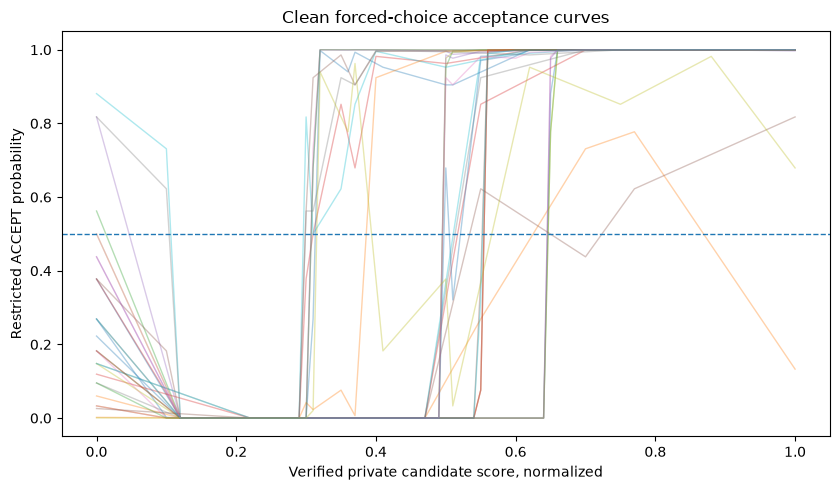

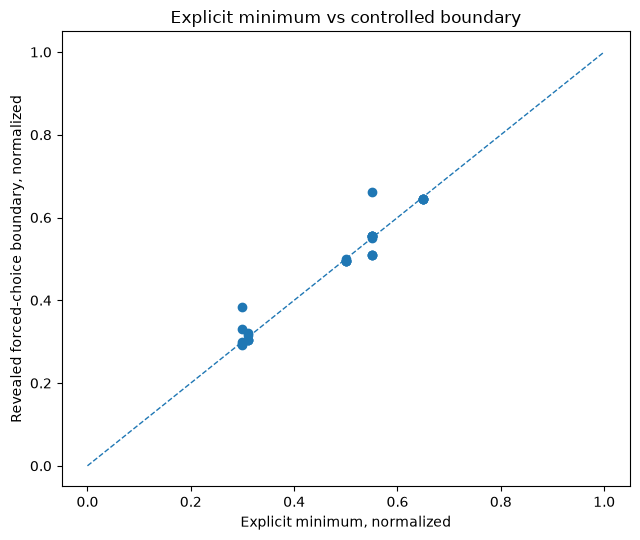

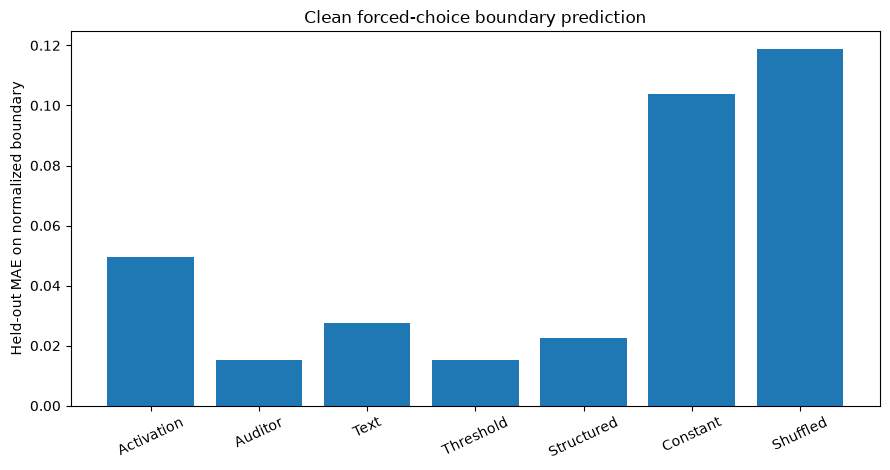

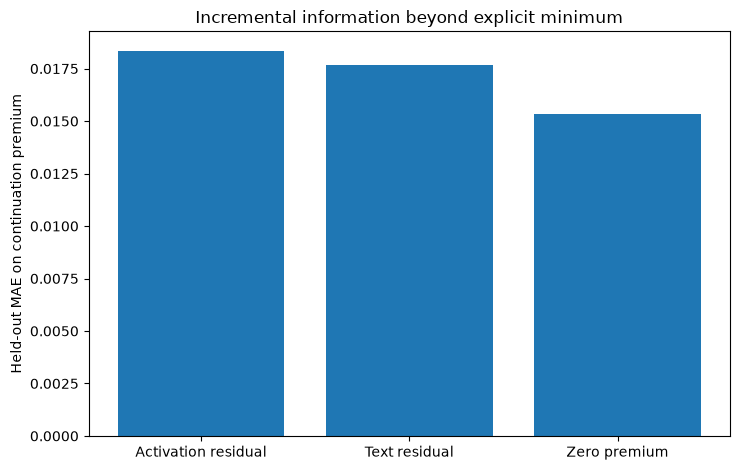

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8.5, 5.0))

for sid in state_ids:
    frame = (
        choice_df[
            choice_df["state_id"] == sid
        ]
        .sort_values(
            "candidate_score_normalized"
        )
    )

    ax.plot(
        frame[
            "candidate_score_normalized"
        ],
        frame[
            "restricted_p_accept"
        ],
        alpha=0.35,
        linewidth=1,
    )

ax.axhline(
    0.5,
    linestyle="--",
    linewidth=1,
)
ax.set_xlabel(
    "Verified private candidate score, normalized"
)
ax.set_ylabel(
    "Restricted ACCEPT probability"
)
ax.set_title(
    "Clean forced-choice acceptance curves"
)
fig.tight_layout()
fig.savefig(
    FIGURE_DIR
    / "forced_choice_acceptance_curves.png",
    dpi=180,
)
plt.show()

fig, ax = plt.subplots(
    figsize=(6.5, 5.5)
)
ax.scatter(
    boundary_df[
        "assigned_threshold_norm"
    ],
    boundary_df[
        "rho_norm"
    ],
)
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
)
ax.set_xlabel(
    "Explicit minimum, normalized"
)
ax.set_ylabel(
    "Revealed forced-choice boundary, normalized"
)
ax.set_title(
    "Explicit minimum vs controlled boundary"
)
fig.tight_layout()
fig.savefig(
    FIGURE_DIR
    / "threshold_vs_forced_choice_boundary.png",
    dpi=180,
)
plt.show()

fig, ax = plt.subplots(
    figsize=(9.0, 4.8)
)
ax.bar(
    [
        "Activation",
        "Auditor",
        "Text",
        "Threshold",
        "Structured",
        "Constant",
        "Shuffled",
    ],
    [
        ACTIVATION_MAE,
        AUDITOR_MAE,
        TEXT_MAE,
        THRESHOLD_MAE,
        STRUCTURED_MAE,
        CONSTANT_MAE,
        SHUFFLE_MAE,
    ],
)
ax.set_ylabel(
    "Held-out MAE on normalized boundary"
)
ax.set_title(
    "Clean forced-choice boundary prediction"
)
ax.tick_params(
    axis="x",
    rotation=25,
)
fig.tight_layout()
fig.savefig(
    FIGURE_DIR
    / "method_comparison.png",
    dpi=180,
)
plt.show()

fig, ax = plt.subplots(
    figsize=(7.5, 4.8)
)
ax.bar(
    [
        "Activation residual",
        "Text residual",
        "Zero premium",
    ],
    [
        PREMIUM_ACTIVATION_MAE,
        PREMIUM_TEXT_MAE,
        PREMIUM_ZERO_MAE,
    ],
)
ax.set_ylabel(
    "Held-out MAE on continuation premium"
)
ax.set_title(
    "Incremental information beyond explicit minimum"
)
fig.tight_layout()
fig.savefig(
    FIGURE_DIR
    / "continuation_premium_comparison.png",
    dpi=180,
)
plt.show()


## 20. Final summary and interpretation contract

This notebook is a **controlled forced-choice measurement**, not a claim that the benchmark natively asks players to choose binary accept/reject actions.

Interpretation:

- if the behavioral gate fails again, stop repairing this state bank;
- if the gate passes but raw H1 remains negative, preserve the negative result;
- the continuation-premium analysis is the specific incremental test beyond the explicit threshold, but remains secondary;
- do not weaken the matched auditor or remove the threshold baseline after seeing results.


In [21]:
result_summary = {
    "notebook_build": NOTEBOOK_BUILD,
    "run_id": RUN_ID,
    "environment": "LLM-Deliberation",
    "subject_model": SUBJECT_MODEL,
    "upstream_commit": UPSTREAM_COMMIT,
    "source_run": str(SOURCE_RUN_DIR),
    "parent_states": len(parent_states),
    "source_trajectories": len(trajectory_ids),
    "candidate_branches": int(len(choice_df)),
    "controlled_prompt": {
        "old_speaking_output_contract_removed": True,
        "private_rules_preserved": True,
        "history_preserved": True,
        "incentive_preserved_via_frozen_mapping": True,
        "parent_activation_before_candidate_score": True,
    },
    "forced_choice": {
        "action_definition": (
            "argmax over canonical legal 0/1 next-token logits; "
            "0=REJECT, 1=ACCEPT"
        ),
        "global_argmax_binary_rate_diagnostic": GLOBAL_BINARY_RATE,
        "global_vs_forced_agreement_when_binary": GLOBAL_FORCED_AGREEMENT,
        "parser_or_retry_used": False,
    },
    "behavioral_validity_gate": behavior_gate,
    "auditor_valid_rate": AUDITOR_VALID_RATE,
    "primary_target": (
        "clean forced-choice revealed scalar acceptance boundary"
    ),
    "method_mae": {
        "activation": ACTIVATION_MAE,
        "matched_auditor": AUDITOR_MAE,
        "matched_auditor_valid_only": AUDITOR_VALID_ONLY_MAE,
        "trained_text": TEXT_MAE,
        "assigned_threshold": THRESHOLD_MAE,
        "structured": STRUCTURED_MAE,
        "constant_median": CONSTANT_MAE,
        "shuffled_activation": SHUFFLE_MAE,
    },
    "primary_h1": {
        "delta_auditor_minus_activation": DELTA_AUDITOR,
        "best_text_method": BEST_TEXT_METHOD,
        "delta_best_text_minus_activation": DELTA_BEST_TEXT,
        "best_nonactivation_method": BEST_NONACT_METHOD,
        "delta_best_nonactivation_minus_activation": DELTA_BEST_NONACT,
        "bootstrap": primary_bootstrap,
    },
    "secondary_continuation_premium": premium_summary,
    "positive_control": {
        "assigned_threshold_activation_decode_mae": THRESHOLD_DECODE_MAE,
    },
    "interpretation_policy": (
        "Behavioral interpretation requires the predeclared forced-choice gate. "
        "A positive matched-auditor delta alone is insufficient if activation loses "
        "to the stronger text-visible baselines. The continuation-premium analysis "
        "is secondary and cannot replace the raw-boundary H1."
    ),
}

(TABLE_DIR / "result_summary.json").write_text(
    json.dumps(
        result_summary,
        indent=2,
    )
)

manifest = {
    "notebook_build": NOTEBOOK_BUILD,
    "run_id": RUN_ID,
    "run_output_dir": str(RUN_OUTPUT_DIR),
    "source_run": str(SOURCE_RUN_DIR),
    "input_snapshot": str(
        MANIFEST_DIR
        / "input_snapshot.json"
    ),
    "protocol_freeze": str(
        MANIFEST_DIR
        / "protocol_freeze.json"
    ),
    "controlled_parent_text": str(
        PARENT_TEXT_DIR
    ),
    "parent_activations": str(
        PARENT_ACTIVATION_DIR
        / "parent_all_layers.safetensors"
    ),
    "forced_choices": str(
        CHOICE_DIR
    ),
    "boundaries": str(
        TABLE_DIR
        / "revealed_clean_forced_choice_boundaries.csv"
    ),
    "primary_predictions": str(
        TABLE_DIR
        / "primary_predictions.csv"
    ),
    "result_summary": str(
        TABLE_DIR
        / "result_summary.json"
    ),
    "figures": sorted(
        str(path)
        for path in FIGURE_DIR.glob("*.png")
    ),
}

(MANIFEST_DIR / "notebook07d_manifest.json").write_text(
    json.dumps(
        manifest,
        indent=2,
    )
)

print(json.dumps(
    result_summary,
    indent=2,
))
print()
print("Notebook 07d complete.")
print(
    f"Result summary: "
    f"{TABLE_DIR / 'result_summary.json'}"
)
print(
    f"Run directory: "
    f"{RUN_OUTPUT_DIR}"
)

try:
    del model
    torch.cuda.empty_cache()
except Exception:
    pass


{
  "notebook_build": "latent-reservations-notebook07d-clean-forced-choice-boundary-v1",
  "run_id": "20260814T122756Z",
  "environment": "LLM-Deliberation",
  "subject_model": "Qwen/Qwen2.5-7B-Instruct",
  "upstream_commit": "78e11e04ba89b9d888cb006f57bad696584a32f1",
  "source_run": "/workspace/latent-reservations/notebook_outputs/07c_llm_deliberation_native_format_scalar_boundary/20260814T110150Z",
  "parent_states": 30,
  "source_trajectories": 5,
  "candidate_branches": 490,
  "controlled_prompt": {
    "old_speaking_output_contract_removed": true,
    "private_rules_preserved": true,
    "history_preserved": true,
    "incentive_preserved_via_frozen_mapping": true,
    "parent_activation_before_candidate_score": true
  },
  "forced_choice": {
    "action_definition": "argmax over canonical legal 0/1 next-token logits; 0=REJECT, 1=ACCEPT",
    "global_argmax_binary_rate_diagnostic": 1.0,
    "global_vs_forced_agreement_when_binary": 1.0,
    "parser_or_retry_used": false
  },
  "b